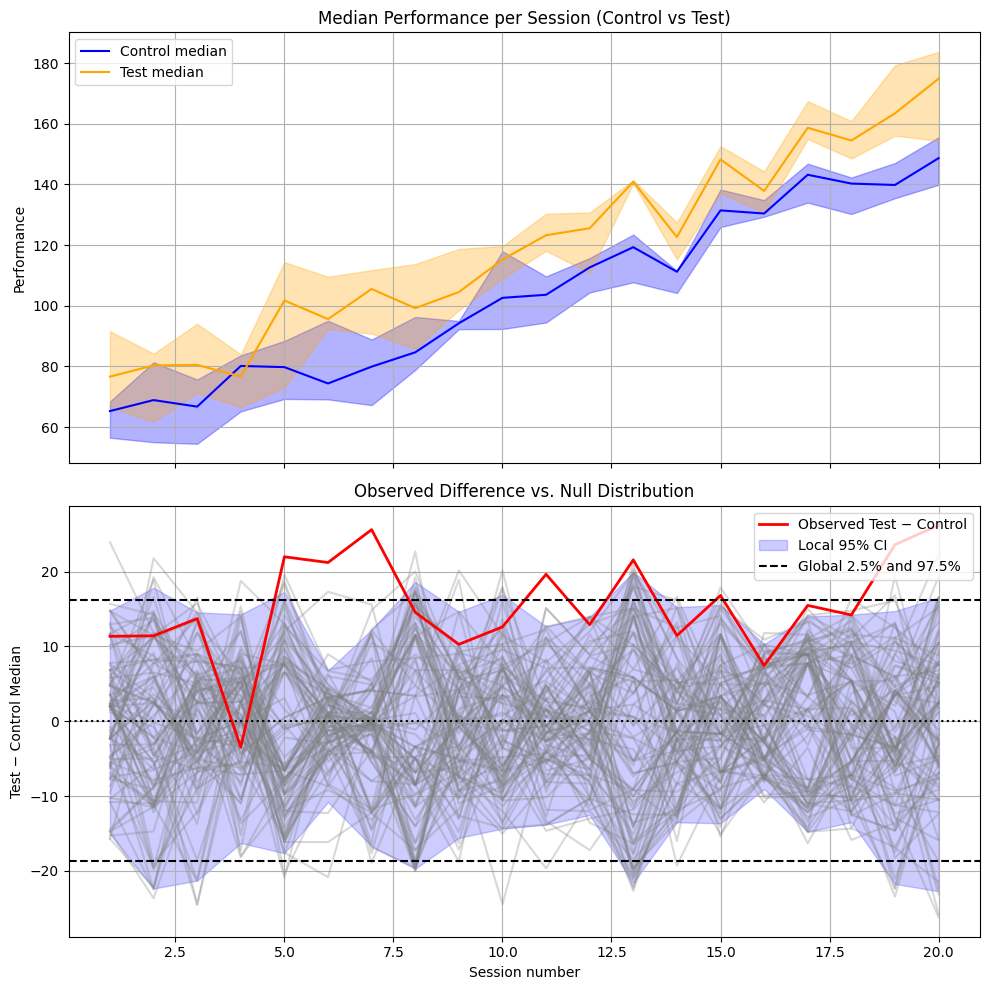

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import math
import random

# Seed
np.random.seed(0)
random.seed(0)

# Simulate data
data = {}
n_animals_per_group = 10
n_sessions = 20

for i in range(1, n_animals_per_group + 1):
    data[f'Control_{i}'] = [[s, np.random.normal(loc=50 + s * 5, scale=15) if np.random.rand() > 0.1 else np.nan] for s in range(1, n_sessions + 1)]
    data[f'Test_{i}'] = [[s, np.random.normal(loc=70 + s * 5, scale=15) if np.random.rand() > 0.1 else np.nan] for s in range(1, n_sessions + 1)]

all_animals = list(data.keys())

# Helper functions
def group_data(animal_ids):
    sessions = defaultdict(list)
    for animal in animal_ids:
        for session, perf in data[animal]:
            if not math.isnan(perf):
                sessions[session].append(perf)
    return sessions

def compute_median_and_iqr(sessions):
    xs = sorted(sessions.keys())
    medians = [np.median(sessions[x]) if sessions[x] else np.nan for x in xs]
    q1 = [np.percentile(sessions[x], 25) if sessions[x] else np.nan for x in xs]
    q3 = [np.percentile(sessions[x], 75) if sessions[x] else np.nan for x in xs]
    return np.array(xs), np.array(medians), np.array(q1), np.array(q3)

def compute_median_per_session(sessions):
    xs = sorted(sessions.keys())
    return np.array([np.median(sessions[x]) if sessions[x] else np.nan for x in xs])

# True group assignment
group_control = [k for k in data if k.startswith('Control')]
group_test = [k for k in data if k.startswith('Test')]

# Compute true medians and IQRs
ctrl_x, ctrl_med, ctrl_q1, ctrl_q3 = compute_median_and_iqr(group_data(group_control))
test_x, test_med, test_q1, test_q3 = compute_median_and_iqr(group_data(group_test))
true_diff = test_med - ctrl_med

# Bootstrap null distribution
n_bootstraps = 100
boot_diffs = []

for _ in range(n_bootstraps):
    shuffled = random.sample(all_animals, len(all_animals))
    pseudo_ctrl = shuffled[:n_animals_per_group]
    pseudo_test = shuffled[n_animals_per_group:]

    ctrl_boot = compute_median_per_session(group_data(pseudo_ctrl))
    test_boot = compute_median_per_session(group_data(pseudo_test))
    boot_diffs.append(test_boot - ctrl_boot)

boot_diffs = np.array(boot_diffs)  # shape: (100, n_sessions)

# Global confidence bounds
all_diffs_flat = boot_diffs.flatten()
global_low = np.percentile(all_diffs_flat, 2.5)
global_high = np.percentile(all_diffs_flat, 97.5)

# Local (per-session) confidence bounds
local_low = np.percentile(boot_diffs, 2.5, axis=0)
local_high = np.percentile(boot_diffs, 97.5, axis=0)

# Plot
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# --- Upper plot: Original medians with IQR shading ---
axs[0].plot(ctrl_x, ctrl_med, label='Control median', color='blue')
axs[0].fill_between(ctrl_x, ctrl_q1, ctrl_q3, color='blue', alpha=0.3)

axs[0].plot(test_x, test_med, label='Test median', color='orange')
axs[0].fill_between(test_x, test_q1, test_q3, color='orange', alpha=0.3)

axs[0].set_ylabel('Performance')
axs[0].set_title('Median Performance per Session (Control vs Test)')
axs[0].legend()
axs[0].grid(True)

# --- Lower plot: Median difference with confidence bands ---
# Bootstrapped null differences (gray)
for i in range(n_bootstraps):
    axs[1].plot(range(1, n_sessions + 1), boot_diffs[i], color='gray', alpha=0.3)

# True difference (red)
axs[1].plot(range(1, n_sessions + 1), true_diff, color='red', label='Observed Test − Control', linewidth=2)

# Local confidence band
axs[1].fill_between(range(1, n_sessions + 1), local_low, local_high, color='blue', alpha=0.2, label='Local 95% CI')

# Global confidence band
axs[1].axhline(global_low, color='black', linestyle='--', label='Global 2.5% and 97.5%')
axs[1].axhline(global_high, color='black', linestyle='--')

axs[1].axhline(0, color='black', linestyle=':')
axs[1].set_xlabel('Session number')
axs[1].set_ylabel('Test − Control Median')
axs[1].set_title('Observed Difference vs. Null Distribution')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


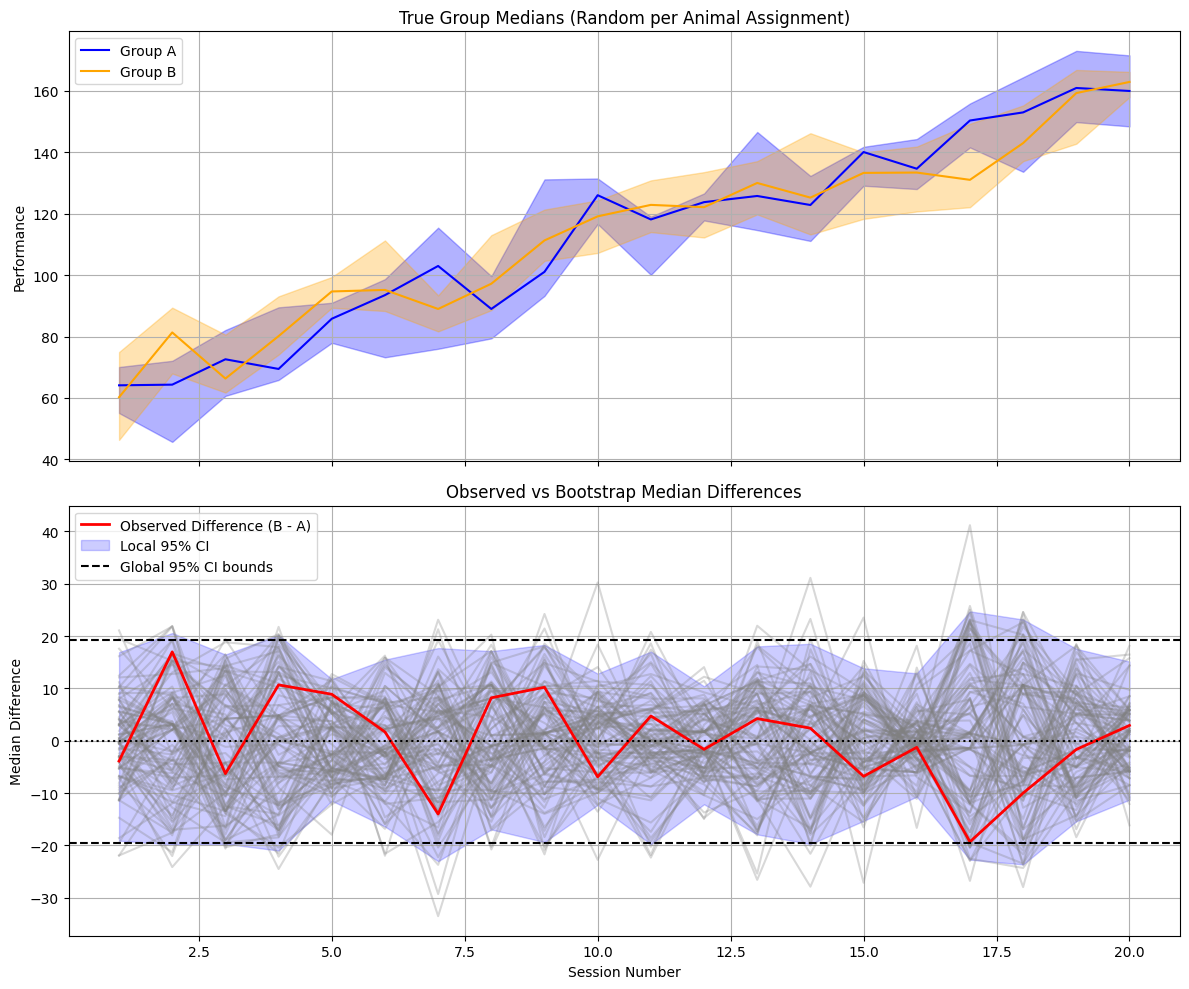

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

np.random.seed(0)
random.seed(0)

# Simulate your dictionary data with 20 animals mixed control/test (for example)
data = {}

n_sessions = 20
n_animals = 20
for i in range(n_animals):
    group = 'Control' if i < 10 else 'Test'
    animal_name = f'{group}_{i%10 + 1}'
    data[animal_name] = [[s, np.random.normal(loc=60 + s * 5 + np.random.choice([-10, 0, 10]), scale=15)
                          if np.random.rand() > 0.1 else np.nan]
                         for s in range(1, n_sessions + 1)]

all_animals = list(data.keys())

def group_data(animal_list):
    sessions = {}
    for animal in animal_list:
        for session, perf in data[animal]:
            if not math.isnan(perf):
                sessions.setdefault(session, []).append(perf)
    return sessions

def compute_median_and_iqr(sessions):
    xs = sorted(sessions.keys())
    medians = [np.median(sessions[x]) if sessions[x] else np.nan for x in xs]
    q1 = [np.percentile(sessions[x], 25) if sessions[x] else np.nan for x in xs]
    q3 = [np.percentile(sessions[x], 75) if sessions[x] else np.nan for x in xs]
    return np.array(xs), np.array(medians), np.array(q1), np.array(q3)

def compute_median_per_session(sessions):
    xs = sorted(sessions.keys())
    return np.array([np.median(sessions[x]) if sessions[x] else np.nan for x in xs])

def random_group_assignment(animal_list):
    group_A = []
    group_B = []
    for animal in animal_list:
        if random.random() < 0.5:
            group_A.append(animal)
        else:
            group_B.append(animal)
    return group_A, group_B

# Assuming your original group lists (control and test) are defined explicitly:
control_animals = [a for a in all_animals if 'Control' in a]
test_animals = [a for a in all_animals if 'Test' in a]

A_sessions = group_data(control_animals)
B_sessions = group_data(test_animals)

A_x, A_med, A_q1, A_q3 = compute_median_and_iqr(A_sessions)
B_x, B_med, B_q1, B_q3 = compute_median_and_iqr(B_sessions)

true_diff = B_med - A_med

# Bootstrap with 100 random independent animal assignments
n_bootstraps = 100
boot_diffs = []

for _ in range(n_bootstraps):
    pseudo_A, pseudo_B = random_group_assignment(all_animals)
    A_boot = compute_median_per_session(group_data(pseudo_A))
    B_boot = compute_median_per_session(group_data(pseudo_B))
    boot_diffs.append(B_boot - A_boot)

boot_diffs = np.array(boot_diffs)

# Global confidence intervals from all bootstrap differences
all_diffs_flat = boot_diffs.flatten()
global_low = np.percentile(all_diffs_flat, 2.5)
global_high = np.percentile(all_diffs_flat, 97.5)

# Local confidence intervals (per session)
local_low = np.percentile(boot_diffs, 2.5, axis=0)
local_high = np.percentile(boot_diffs, 97.5, axis=0)

# Plot results
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Upper plot: True group medians with IQR shading
axs[0].plot(A_x, A_med, label='Group A', color='blue')
axs[0].fill_between(A_x, A_q1, A_q3, color='blue', alpha=0.3)

axs[0].plot(B_x, B_med, label='Group B', color='orange')
axs[0].fill_between(B_x, B_q1, B_q3, color='orange', alpha=0.3)

axs[0].set_ylabel('Performance')
axs[0].set_title('True Group Medians (Random per Animal Assignment)')
axs[0].legend()
axs[0].grid(True)

# Lower plot: Bootstrap differences + true difference + confidence bands
for i in range(n_bootstraps):
    axs[1].plot(range(1, n_sessions + 1), boot_diffs[i], color='gray', alpha=0.3)

axs[1].plot(range(1, n_sessions + 1), true_diff, color='red', linewidth=2, label='Observed Difference (B - A)')
axs[1].fill_between(range(1, n_sessions + 1), local_low, local_high, color='blue', alpha=0.2, label='Local 95% CI')

axs[1].axhline(global_low, color='black', linestyle='--', label='Global 95% CI bounds')
axs[1].axhline(global_high, color='black', linestyle='--')
axs[1].axhline(0, color='black', linestyle=':')

axs[1].set_xlabel('Session Number')
axs[1].set_ylabel('Median Difference')
axs[1].set_title('Observed vs Bootstrap Median Differences')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [7]:
data

{'Control_1': [[1, 66.77744691106112],
  [2, 71.7095169245636],
  [3, 84.17447315410568],
  [4, 88.39034321629825],
  [5, 77.93843493396349],
  [6, 94.59523995326569],
  [7, 126.21565781657955],
  [8, 108.1392400341298],
  [9, 66.70515276248882],
  [10, 129.8042789316054],
  [11, 119.01820739972095],
  [12, 97.59205199769508],
  [13, 98.82582996125365],
  [14, 150.93208405459097],
  [15, nan],
  [16, 133.71299106786557],
  [17, 164.5960399240321],
  [18, 114.40594714062482],
  [19, 174.26163092847685],
  [20, 156.72956291235806]],
 'Control_2': [[1, 40.113553425121225],
  [2, 52.09632622083261],
  [3, 82.11563668765096],
  [4, 96.38090097704475],
  [5, 84.5804322479533],
  [6, nan],
  [7, 100.46437301221026],
  [8, 76.63394596681371],
  [9, 131.1418155627816],
  [10, 122.88211251578298],
  [11, nan],
  [12, 136.42455349762034],
  [13, 149.94416751821402],
  [14, 121.54047546187388],
  [15, 127.91010787165968],
  [16, 156.9849365959569],
  [17, 131.95634470584164],
  [18, 131.9229775972